# Configuration

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

Standard BS switch rate: 24.69%
m-out-of-n BS switch rate: 43.26%


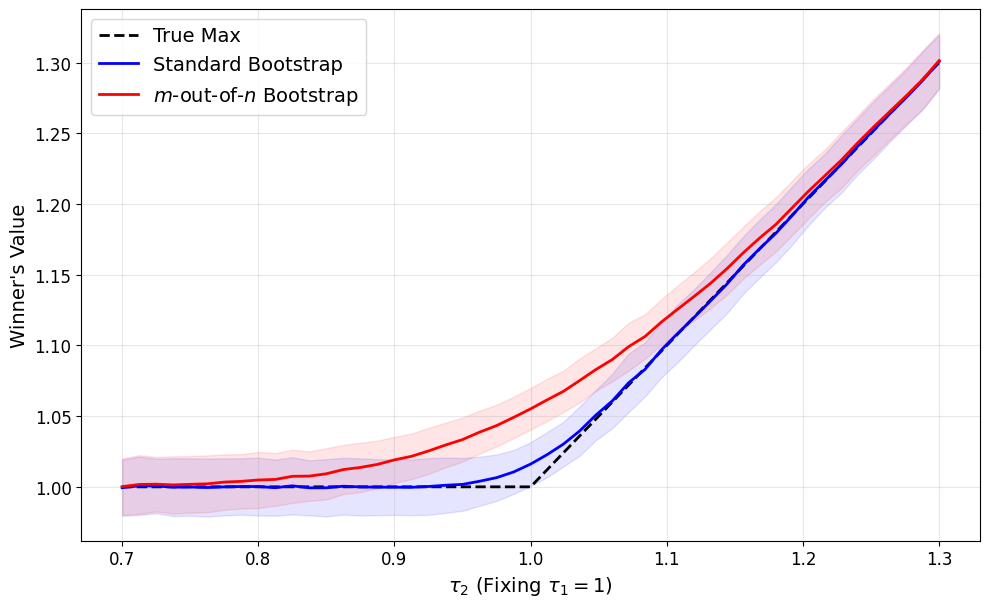

In [31]:
# --- Setup Parameters ---
np.random.seed(42) 
N = 2500           # Original Sample Size
m = int(N**0.6)    # 
sigma = 1.0        # Population standard deviation

# Simulation Settings
n_sim = 1000        # Number of dataset realizations per grid point (Smooths the curve)
n_boot = 500      # Number of bootstrap draws per dataset
tau1 = 1.0
tau2_range = np.concatenate((np.linspace(0.7, 1.0, 25), np.linspace(1.0, 1.3, 26)[1:])) # Grid of True Difference

# --- 1. Panel A: The Mechanism (Single Tie Dataset) ---
# We still use a SINGLE "dead tie" dataset for Panel A to illustrate 
# the distribution shape clearly (the "Lens").
data_tie = np.random.normal(0, sigma, N)

# Run Bootstrap on this single tie dataset
boot_means_N = []
boot_means_m = []

# Vectorized Bootstrap for speed
# Resample indices: (N, n_boot)
idx_N = np.random.randint(0, N, (n_boot, N))
idx_m = np.random.randint(0, N, (n_boot, m))

# Compute means
bs_means_N = np.mean(data_tie[idx_N], axis=1)
bs_means_m = np.mean(data_tie[idx_m], axis=1)

# --- 2. Panel B & C: Value Function across Grid (Multiple Realizations) ---
# Storage for results
# Shape: (len(tau2_range), n_sim)
results_std_bs = np.zeros((len(tau2_range), n_sim))
results_moon_bs = np.zeros((len(tau2_range), n_sim))
switch_rates_N = np.zeros((len(tau2_range), n_sim))
switch_rates_m = np.zeros((len(tau2_range), n_sim))
true_max = np.maximum(tau1, tau2_range)

for i, t2 in enumerate(tau2_range):
    # 1. Generate n_sim datasets at once
    # Shape: (n_sim, N)
    # Arm 1 is always 0, Arm 2 is t2
    # We define the empirical means directly to save memory/time on raw data generation
    # The empirical mean of a dataset of size N follows N(mu, sigma^2/N)
    
    # These are the "observed means" for 100 different researchers running the experiment
    emp_mu1 = np.random.normal(tau1, sigma/np.sqrt(N), n_sim)
    emp_mu2 = np.random.normal(t2, sigma/np.sqrt(N), n_sim)
    
    # 2. Run Bootstrap for EACH simulation
    # We use the parametric sampling equivalent here for computational feasibility 
    # (running raw resampling 50 * 100 * 1000 times is too slow for a demo).
    # This is mathematically equivalent to resampling from the data distribution.
    
    # For each sim (j), we draw n_boot bootstrap samples
    # Standard BS: Variance = sigma^2/N
    # m-out-of-n BS: Variance = sigma^2/m
    
    for j in range(n_sim):
        emp_winner = np.argmax(np.array([emp_mu1[j], emp_mu2[j]]))

        # Bootstrap distribution centered at the observed mean (emp_mu[j])
        bs_dist_N_1 = np.random.normal(emp_mu1[j], sigma/np.sqrt(N), n_boot)
        bs_dist_N_2 = np.random.normal(emp_mu2[j], sigma/np.sqrt(N), n_boot)

        std_bs_winners = np.concatenate((bs_dist_N_1[:, np.newaxis], bs_dist_N_2[:, np.newaxis]), axis=1).argmax(axis=1)
        
        bs_dist_m_1 = np.random.normal(emp_mu1[j], sigma/np.sqrt(m), n_boot)
        bs_dist_m_2 = np.random.normal(emp_mu2[j], sigma/np.sqrt(m), n_boot)

        moon_bs_winners = np.concatenate((bs_dist_m_1[:, np.newaxis], bs_dist_m_2[:, np.newaxis]), axis=1).argmax(axis=1)
        
        # The Estimator: E[max(mu1*, mu2*)]
        results_std_bs[i, j] = np.mean(np.maximum(bs_dist_N_1, bs_dist_N_2))
        results_moon_bs[i, j] = np.mean(np.maximum(bs_dist_m_1, bs_dist_m_2))

        # Calculate switch rates
        switch_rates_N[i, j] = np.mean(std_bs_winners != emp_winner)
        switch_rates_m[i, j] = np.mean(moon_bs_winners != emp_winner)

# Aggregate results (Mean and Std Dev across the n_sim realizations)
mean_std_bs = np.mean(results_std_bs, axis=1)
std_std_bs = np.std(results_std_bs, axis=1)

mean_moon_bs = np.mean(results_moon_bs, axis=1)
std_moon_bs = np.std(results_moon_bs, axis=1)

# Calculate Gradients on the Averaged Curve (Smoothing the output for cleaner derivative)
# We use a light gaussian filter to ensure numerical derivatives aren't dominated by MC noise
grad_N = np.gradient(gaussian_filter1d(mean_std_bs, 1), tau2_range)
grad_m = np.gradient(gaussian_filter1d(mean_moon_bs, 1), tau2_range)

# Print switch rates for the 25th grid point where tau1 = tau2
print('Standard BS switch rate: {:.2%}'.format(switch_rates_N[24].mean()))
print('m-out-of-n BS switch rate: {:.2%}'.format(switch_rates_m[24].mean()))

# --- 3. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# PANEL B: The Value Function (with Bands)
ax.plot(tau2_range, true_max, 'k--', label='True Max', linewidth=2)

# Standard BS
ax.plot(tau2_range, mean_std_bs, 'b-', label='Standard Bootstrap', linewidth=2)
ax.fill_between(tau2_range, mean_std_bs - std_std_bs, mean_std_bs + std_std_bs, color='blue', alpha=0.1)

# m-out-of-n BS
ax.plot(tau2_range, mean_moon_bs, 'r-', label=r'$m$-out-of-$n$ Bootstrap', linewidth=2)
ax.fill_between(tau2_range, mean_moon_bs - std_moon_bs, mean_moon_bs + std_moon_bs, color='red', alpha=0.1)

ax.set_xlabel(r"$\tau_2$ (Fixing $\tau_1=1$)", fontsize=14)
ax.set_ylabel("Winner's Value", fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../figures/m_out_of_n_vs_standard_bootstrap.pdf')
plt.show()

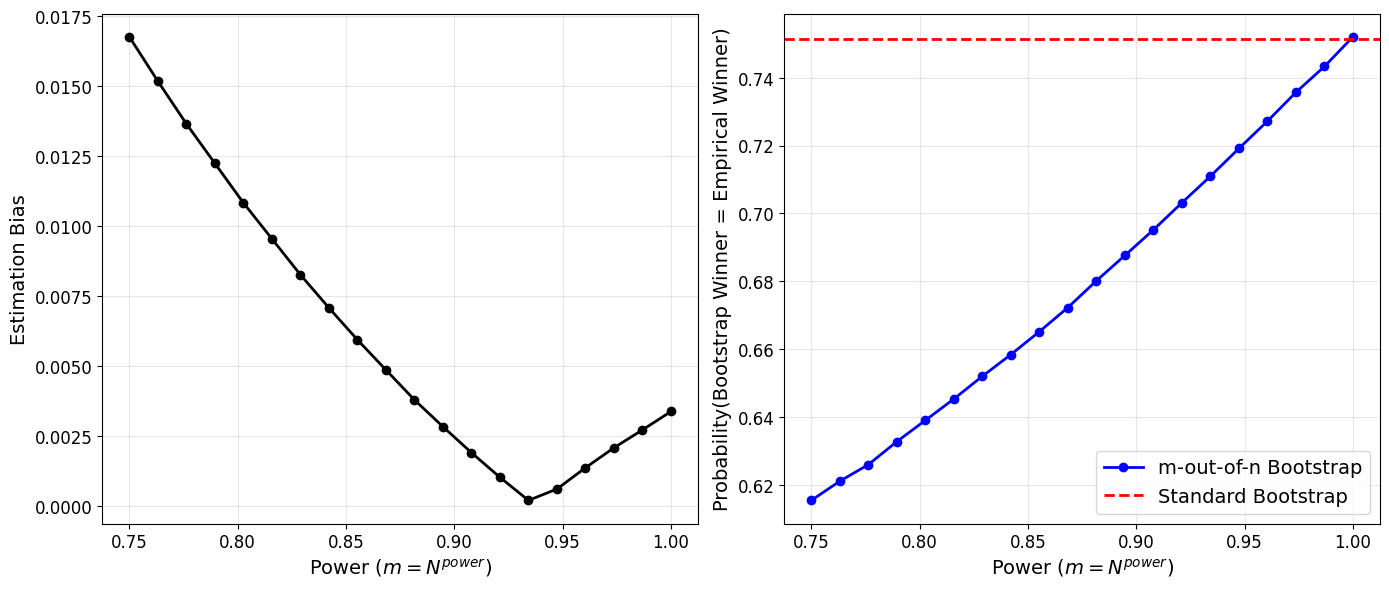

In [41]:
# --- Parameters ---
N = 2500
sigma = 1.0
n_sims = 5000   # Number of researchers/datasets (Outer Loop)
n_boot = 500   # Number of bootstrap draws per dataset (Inner Loop)
tau1 = 1
tau2 = 1       # Tie condition

# True value
true_max = max(tau1, tau2)

# Grid for Power p
p_range = np.linspace(0.75, 1.0, 20)
m_values = [int(N**p) for p in p_range]

# --- Step 1: Generate "Observed" Datasets ---
# We generate the empirical means for n_sims researchers.
# The empirical mean follows N(true_mean, sigma^2/N)
np.random.seed(42)
hat_tau1 = np.random.normal(tau1, sigma/np.sqrt(N), n_sims)
hat_tau2 = np.random.normal(tau2, sigma/np.sqrt(N), n_sims)

# Identify Empirical Winners for each dataset
# shape: (n_sims,)
emp_winner_vals = np.maximum(hat_tau1, hat_tau2)
# 0 for Arm 1, 1 for Arm 2
emp_winner_idxs = np.where(hat_tau1 > hat_tau2, 0, 1)

# Storage for results
abs_bias_list = []
agreement_rate_list = []


# --- Step 2: Iterate over Subsample Sizes (m) ---
for m in m_values:
    # We use Monte Carlo simulation to generate bootstrap draws.
    # A bootstrap mean of size m drawn from a dataset with mean hat_mu 
    # follows N(hat_mu, sigma^2/m).
    
    # Generate Bootstrap Means for Arm 1 and Arm 2
    # shape: (n_sims, n_boot)
    bs_means_1 = np.random.normal(hat_tau1[:, None], sigma/np.sqrt(m), (n_sims, n_boot))  # shape = (n_sims, n_boot)
    bs_means_2 = np.random.normal(hat_tau2[:, None], sigma/np.sqrt(m), (n_sims, n_boot))  # shape = (n_sims, n_boot)
    
    # Determine Bootstrap Winners
    bs_winner_vals = np.maximum(bs_means_1, bs_means_2)  # shape = (n_sims, n_boot)
    bs_winner_idxs = np.where(bs_means_1 > bs_means_2, 0, 1)  # shape = (n_sims, n_boot)
    
    # --- Metric 1: Agreement Rate ---
    # How often does BS winner agree with Empirical Winner?
    # emp_winner_idxs is (n_sims,), need to broadcast to (n_sims, n_boot)
    agreement = (bs_winner_idxs == emp_winner_idxs[:, None])
    avg_agreement_rate = np.mean(agreement)
    agreement_rate_list.append(avg_agreement_rate)
    
    # --- Metric 2: Estimated Winner's Curse (Algorithm 2 from paper) ---
    # Bias = E[BS_Winner_Val - Original_Estimate_of_BS_Winner]
    
    # We need the "Original Estimate" corresponding to the arm that won in the bootstrap
    # If BS winner was 0, grab hat_tau1. If 1, grab hat_tau2.
    # shape: (n_sims, n_boot)
    orig_est_of_bs_winner = np.where(bs_winner_idxs == 0, hat_tau1[:, None], hat_tau2[:, None])
    
    # Calculate Bias for each bootstrap draw
    bias_draws = bs_winner_vals - orig_est_of_bs_winner
    
    # Average over bootstrap draws to get the Estimator of Bias for each dataset
    # shape: (n_sims,)
    estimated_wc = np.mean(bias_draws, axis=1)
    
    # Correct the estimator
    corrected_estimates = emp_winner_vals - estimated_wc
    
    # Calculate Absolute Bias of the Corrected Estimator vs Truth
    # Bias = E[Corrected] - True. We take Absolute value.
    # We compute the mean bias across all simulations first
    avg_corrected_val = np.mean(corrected_estimates)
    final_bias = np.abs(avg_corrected_val - true_max)
    abs_bias_list.append(final_bias)

# --- Step 2.5: Aggreement Rate of Standard Bootstrap ---
# Generate Bootstrap Means for Arm 1 and Arm 2
# shape: (n_sims, n_boot)
bs_means_1 = np.random.normal(hat_tau1[:, None], sigma/np.sqrt(N), (n_sims, n_boot))  # shape = (n_sims, n_boot)
bs_means_2 = np.random.normal(hat_tau2[:, None], sigma/np.sqrt(N), (n_sims, n_boot))  # shape = (n_sims, n_boot)

# Determine Bootstrap Winners
bs_winner_vals = np.maximum(bs_means_1, bs_means_2)  # shape = (n_sims, n_boot)
bs_winner_idxs = np.where(bs_means_1 > bs_means_2, 0, 1)  # shape = (n_sims, n_boot)

# --- Metric 1: Agreement Rate ---
# How often does BS winner agree with Empirical Winner?
# emp_winner_idxs is (n_sims,), need to broadcast to (n_sims, n_boot)
std_bs_agreement = (bs_winner_idxs == emp_winner_idxs[:, None])
std_bs_agreement_rate = np.mean(std_bs_agreement)


# --- Step 3: Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Absolute Bias
axes[0].plot(p_range, abs_bias_list, 'k-o', linewidth=2, label='Corrected Estimator Bias')
axes[0].set_xlabel(r'Power ($m = N^{power}$)', fontsize=14)
axes[0].set_ylabel(r'Estimation Bias', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelsize=12)

# # Highlight optimal p
# min_bias_idx = np.argmin(abs_bias_list)
# optimal_p = p_range[min_bias_idx]
# axes[0].axvline(optimal_p, color='red', linestyle='--', alpha=0.5)
# axes[0].text(optimal_p, max(abs_bias_list)*0.9, f'Optimal\n$p \\approx {optimal_p:.4f}$', color='red', ha='center')

# Panel B: Agreement Rate
axes[1].plot(p_range, agreement_rate_list, 'b-o', linewidth=2, label='m-out-of-n Bootstrap')
axes[1].axhline(std_bs_agreement_rate, color='red', linestyle='--', linewidth=2, label='Standard Bootstrap')
axes[1].set_xlabel(r'Power ($m = N^{power}$)', fontsize=14)
axes[1].set_ylabel('Probability(Bootstrap Winner = Empirical Winner)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=14)
axes[1].tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('../figures/subsampling_size_tradeoff.pdf')
plt.show()

(3000, 1000)